# Principal Component Analysis (PCA) Implementation
Creating a custom dataset and implementing PCA from scratch

## Explanation of the Implementation:

1. **Data Creation**:
   - Generated 3 correlated features
   - x2 is correlated with x1
   - x3 is correlated with both x1 and x2

2. **PCA Steps**:
   - Standardization of features
   - Computation of covariance matrix
   - Eigenvalue decomposition
   - Selection of principal components
   - Data transformation

3. **Visualization**:
   - Left plot shows original data (first 2 dimensions)
   - Right plot shows transformed data in principal component space

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Create a custom dataset
np.random.seed(42)
n_samples = 100

# Generate correlated features
x1 = np.random.normal(0, 1, n_samples)
x2 = 0.7 * x1 + np.random.normal(0, 0.3, n_samples)
x3 = 0.5 * x1 - 0.2 * x2 + np.random.normal(0, 0.2, n_samples)

# Combine features into a matrix
X = np.column_stack((x1, x2, x3))

print("Original dataset shape:", X.shape)
print("\nFirst 5 samples of original data:")
print(X[:5])

Original dataset shape: (100, 3)

First 5 samples of original data:
[[ 0.49671415 -0.07691132  0.33529681]
 [-0.1382643  -0.22297861  0.08762048]
 [ 0.64768854  0.35056762  0.47034099]
 [ 1.52302986  0.82543772  0.80718779]
 [-0.23415337 -0.21229308 -0.35015195]]


In [8]:
# Implement PCA from scratch
def pca_from_scratch(X, n_components):
    # Step 1: Standardize the data
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0)
    X_standardized = (X - X_mean) / X_std
    
    # Step 2: Calculate covariance matrix
    cov_matrix = np.cov(X_standardized.T)
    
    # Step 3: Calculate eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # Step 4: Sort eigenvalues and eigenvectors in descending order
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Step 5: Select top n_components
    selected_vectors = eigenvectors[:, :n_components]
    
    # Step 6: Transform the data
    X_transformed = np.dot(X_standardized, selected_vectors)
    
    return X_transformed, eigenvalues, selected_vectors

# Apply PCA with 2 components
X_transformed, eigenvalues, components = pca_from_scratch(X, n_components=2)

In [9]:
print("Transformed dataset shape:", X_transformed.shape)
print("\nFirst 5 samples of transformed data:")
print(X_transformed[:5])
print("\nExplained variance ratio:", eigenvalues / np.sum(eigenvalues))

Transformed dataset shape: (100, 2)

First 5 samples of transformed data:
[[-0.85581523  0.5836438 ]
 [ 0.01284222  0.35573349]
 [-1.5013367   0.37852086]
 [-2.93019244  0.41231842]
 [ 0.63210764 -0.40476944]]

Explained variance ratio: [0.88666639 0.09381473 0.01951888]


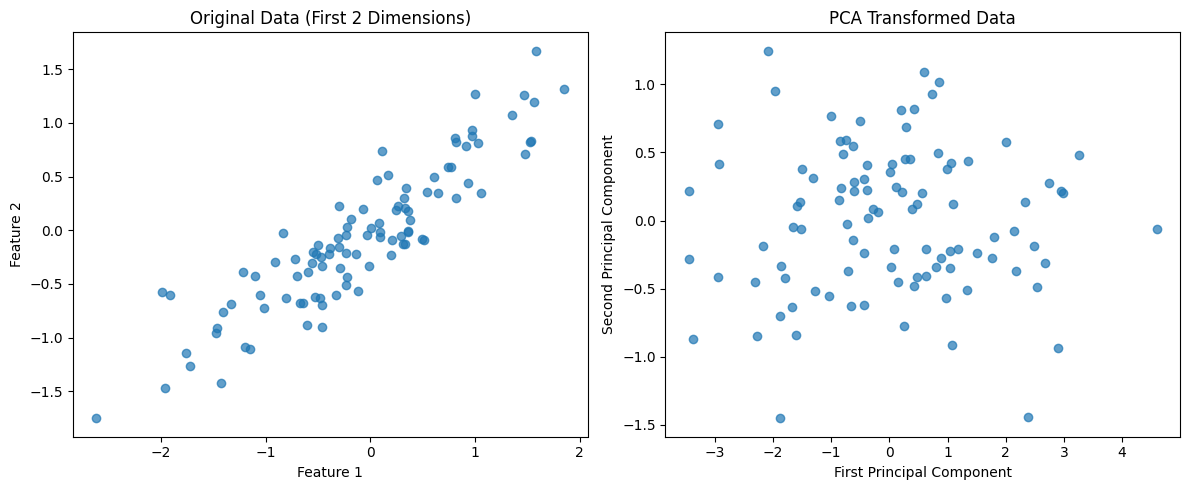

In [10]:
# Visualize original data (first two dimensions)
plt.figure(figsize=(12, 5))

plt.subplot(121)
plt.scatter(X[:, 0], X[:, 1], alpha=0.7)
plt.title('Original Data (First 2 Dimensions)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Visualize transformed data
plt.subplot(122)
plt.scatter(X_transformed[:, 0], X_transformed[:, 1], alpha=0.7)
plt.title('PCA Transformed Data')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA

"""


"""